In [67]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer

from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import root_mean_squared_error

import matplotlib.pyplot as plt

import xgboost as xgb
from xgboost import DMatrix

In [3]:
!which python

/Users/isaachurwitz/opt/anaconda3/envs/ml-zoomcamp/bin/python


### Dataset

In this homework, we will use the Students Performance in 2024 JAMB dataset from [Kaggle](https://www.kaggle.com/datasets/idowuadamo/students-performance-in-2024-jamb).

Here's a wget-able [link](https://github.com/alexeygrigorev/datasets/raw/refs/heads/master/jamb_exam_results.csv):

```bash
wget https://github.com/alexeygrigorev/datasets/raw/refs/heads/master/jamb_exam_results.csv
```

The goal of this homework is to create a regression model for predicting the performance of students on a standardized test (column `'JAMB_Score'`).

In [4]:
!wget https://github.com/alexeygrigorev/datasets/raw/refs/heads/master/jamb_exam_results.csv

--2024-10-31 06:53:33--  https://github.com/alexeygrigorev/datasets/raw/refs/heads/master/jamb_exam_results.csv
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/alexeygrigorev/datasets/refs/heads/master/jamb_exam_results.csv [following]
--2024-10-31 06:53:33--  https://raw.githubusercontent.com/alexeygrigorev/datasets/refs/heads/master/jamb_exam_results.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8002::154, 2606:50c0:8003::154, 2606:50c0:8000::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8002::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 391501 (382K) [text/plain]
Saving to: ‘jamb_exam_results.csv’

jamb_exam_results.c 100%[===================>] 382.33K  --.-KB/s    in 0.1s    

2024-10-31 06:53:34 (3.16 MB/s) - ‘

In [5]:
df = pd.read_csv('jamb_exam_results.csv')

In [6]:
df.head()

,JAMB_Score,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,School_Type,School_Location,Extra_Tutorials,Access_To_Learning_Materials,Parent_Involvement,IT_Knowledge,Student_ID,Age,Gender,Socioeconomic_Status,Parent_Education_Level,Assignments_Completed
0,192,22,78,4,12.4,Public,Urban,Yes,Yes,High,Medium,1,17,Male,Low,Tertiary,2
1,207,14,88,4,2.7,Public,Rural,No,Yes,High,High,2,15,Male,High,NaN,1
2,182,29,87,2,9.6,Public,Rural,Yes,Yes,High,Medium,3,20,Female,High,Tertiary,2
3,210,29,99,2,2.6,Public,Urban,No,Yes,Medium,High,4,22,Female,Medium,Tertiary,1
4,199,12,98,3,8.8,Public,Urban,No,Yes,Medium,Medium,5,22,Female,Medium,Tertiary,1


### Preparing the dataset 

First, let's make the names lowercase:

```python
df.columns = df.columns.str.lower().str.replace(' ', '_')
```

Preparation:

* Remove the `student_id` column.
* Fill missing values with zeros.
* Do train/validation/test split with 60%/20%/20% distribution. 
* Use the `train_test_split` function and set the `random_state` parameter to 1.
* Use `DictVectorizer(sparse=True)` to turn the dataframes into matrices.

In [7]:
df.columns = df.columns.str.lower().str.replace(" ", "-")

In [8]:
df.head()

,jamb_score,study_hours_per_week,attendance_rate,teacher_quality,distance_to_school,school_type,school_location,extra_tutorials,access_to_learning_materials,parent_involvement,it_knowledge,student_id,age,gender,socioeconomic_status,parent_education_level,assignments_completed
0,192,22,78,4,12.4,Public,Urban,Yes,Yes,High,Medium,1,17,Male,Low,Tertiary,2
1,207,14,88,4,2.7,Public,Rural,No,Yes,High,High,2,15,Male,High,NaN,1
2,182,29,87,2,9.6,Public,Rural,Yes,Yes,High,Medium,3,20,Female,High,Tertiary,2
3,210,29,99,2,2.6,Public,Urban,No,Yes,Medium,High,4,22,Female,Medium,Tertiary,1
4,199,12,98,3,8.8,Public,Urban,No,Yes,Medium,Medium,5,22,Female,Medium,Tertiary,1


In [9]:
df.shape

(5000, 17)

In [10]:
df = df.drop('student_id', axis=1)

In [14]:
df.isna().sum()

jamb_score                        0
study_hours_per_week              0
attendance_rate                   0
teacher_quality                   0
distance_to_school                0
school_type                       0
school_location                   0
extra_tutorials                   0
access_to_learning_materials      0
parent_involvement                0
it_knowledge                      0
age                               0
gender                            0
socioeconomic_status              0
parent_education_level          891
assignments_completed             0
dtype: int64

In [15]:
df = df.fillna(0)

In [16]:
df.isna().sum()

jamb_score                      0
study_hours_per_week            0
attendance_rate                 0
teacher_quality                 0
distance_to_school              0
school_type                     0
school_location                 0
extra_tutorials                 0
access_to_learning_materials    0
parent_involvement              0
it_knowledge                    0
age                             0
gender                          0
socioeconomic_status            0
parent_education_level          0
assignments_completed           0
dtype: int64

In [19]:
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_train_full, test_size=0.25, random_state=1)

y_train_full = df_train_full['jamb_score'].values
y_train = df_train['jamb_score'].values
y_val = df_val['jamb_score'].values
y_test = df_test['jamb_score'].values

del df_train_full['jamb_score']
del df_train['jamb_score']
del df_val['jamb_score']
del df_test['jamb_score']



In [20]:
assert len(df_train) == len(y_train)
assert len(df_val) == len(y_val) 
assert len(df_test) == len(y_test)

In [23]:
train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')

dv = DictVectorizer(sparse=True)

X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)



In [21]:
y_train

array([145, 231, 161, ..., 216, 234, 103])

## Question 1

Let's train a decision tree regressor to predict the `jamb_score` variable. 

* Train a model with `max_depth=1`.


Which feature is used for splitting the data?

* `study_hours_per_week`
* `attendance_rate`
* `teacher_quality`
* `distance_to_school`

In [35]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=1)

In [29]:
dv.feature_names_

['access_to_learning_materials=No',
 'access_to_learning_materials=Yes',
 'age',
 'assignments_completed',
 'attendance_rate',
 'distance_to_school',
 'extra_tutorials=No',
 'extra_tutorials=Yes',
 'gender=Female',
 'gender=Male',
 'it_knowledge=High',
 'it_knowledge=Low',
 'it_knowledge=Medium',
 'parent_education_level',
 'parent_education_level=Primary',
 'parent_education_level=Secondary',
 'parent_education_level=Tertiary',
 'parent_involvement=High',
 'parent_involvement=Low',
 'parent_involvement=Medium',
 'school_location=Rural',
 'school_location=Urban',
 'school_type=Private',
 'school_type=Public',
 'socioeconomic_status=High',
 'socioeconomic_status=Low',
 'socioeconomic_status=Medium',
 'study_hours_per_week',
 'teacher_quality']

In [36]:
print(export_text(dt, feature_names=dv.feature_names_))

|--- study_hours_per_week <= 18.50
|   |--- value: [155.24]
|--- study_hours_per_week >  18.50
|   |--- value: [188.59]



answer: study_hours_per_week

## Question 2

Train a random forest model with these parameters:

* `n_estimators=10`
* `random_state=1`
* `n_jobs=-1` (optional - to make training faster)


What's the RMSE of this model on validation?

* 22.13
* 42.13
* 62.13
* 82.12

In [39]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)

rmse = root_mean_squared_error(y_val, y_pred)
print(f'Validation rmse: {rmse:.05f}')

Validation rmse: 42.13724


answer: 42.13

## Question 3

Now let's experiment with the `n_estimators` parameter

* Try different values of this parameter from 10 to 200 with step 10.
* Set `random_state` to `1`.
* Evaluate the model on the validation dataset.


After which value of `n_estimators` does RMSE stop improving?
Consider 3 decimal places for calculating the answer.

- 10
- 25
- 80
- 200

In [47]:
scores = []
for n in range(10, 201, 10):
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    
    rmse = round(root_mean_squared_error(y_val, y_pred), 3)
    scores.append([n, rmse])
    #print(f'n_estimators: {n} ----> validation rmse: {rmse:.03f}')

df_scores = pd.DataFrame(scores, columns=['n_estimators', 'val_rmse'])

In [48]:
df_scores

,n_estimators,val_rmse
0,10,42.137
1,20,41.461
2,30,41.106
3,40,40.917
4,50,40.852
5,60,40.784
6,70,40.677
7,80,40.539
8,90,40.504
9,100,40.517


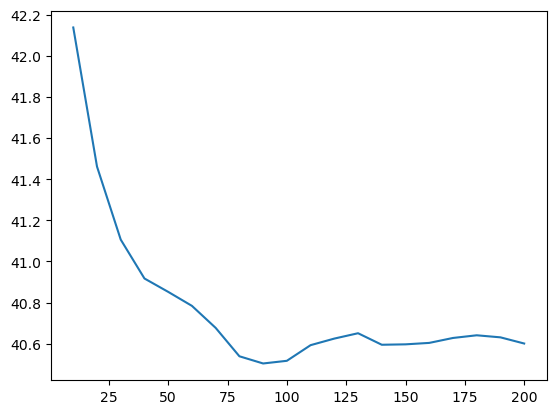

In [50]:
plt.plot(df_scores['n_estimators'], df_scores['val_rmse'])

answer: 80

## Question 4

Let's select the best `max_depth`:

* Try different values of `max_depth`: `[10, 15, 20, 25]`
* For each of these values,
  * try different values of `n_estimators` from 10 till 200 (with step 10)
  * calculate the mean RMSE 
* Fix the random seed: `random_state=1`


What's the best `max_depth`, using the mean RMSE?

* 10
* 15
* 20
* 25

In [51]:
mean_scores = []

for md in [10, 15, 20, 25]:
    scores = []
    for n in range(10, 201, 10):
        rf = RandomForestRegressor(max_depth=md, n_estimators=n, random_state=1, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        
        rmse = round(root_mean_squared_error(y_val, y_pred), 3)
        scores.append(rmse)
    mean_scores.append([md, np.mean(scores)])
    #print(f'n_estimators: {n} ----> validation rmse: {rmse:.03f}')
df_md_scores = pd.DataFrame(mean_scores, columns=['max_depth', 'mean_val_rmse'])    

In [52]:
df_md_scores

,max_depth,mean_val_rmse
0,10,40.39240
1,15,40.73535
2,20,40.73970
3,25,40.78785


answer: The best amx_depth is 10

# Question 5

We can extract feature importance information from tree-based models. 

At each step of the decision tree learning algorithm, it finds the best split. 
When doing it, we can calculate "gain" - the reduction in impurity before and after the split. 
This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the
[`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_)
field. 

For this homework question, we'll find the most important feature:

* Train the model with these parameters:
  * `n_estimators=10`,
  * `max_depth=20`,
  * `random_state=1`,
  * `n_jobs=-1` (optional)
* Get the feature importance information from this model


What's the most important feature (among these 4)? 

* `study_hours_per_week`
* `attendance_rate`
* `distance_to_school`
* `teacher_quality`

In [53]:
rf = RandomForestRegressor(n_estimators=10,
                          max_depth=20,
                          random_state=1,
                          n_jobs=-1)
rf.fit(X_train, y_train)
# y_pred = rf.predict(X_val)


RandomForestRegressor(max_depth=20, n_estimators=10, n_jobs=-1, random_state=1)

In [60]:
f_impts = []
for i, f in enumerate(dv.feature_names_):
    f_impts.append([f, round(rf.feature_importances_[i], 3)])

df_feature_impt = pd.DataFrame(f_impts, columns=['feature', 'feature_importance'])
    

In [61]:
df_feature_impt.sort_values(['feature_importance'], ascending=False)

,feature,feature_importance
27,study_hours_per_week,0.248
4,attendance_rate,0.150
5,distance_to_school,0.136
28,teacher_quality,0.083
2,age,0.069
3,assignments_completed,0.032
24,socioeconomic_status=High,0.026
17,parent_involvement=High,0.023
10,it_knowledge=High,0.018
15,parent_education_level=Secondary,0.017


answer: study_hours_per_week

## Question 6

Now let's train an XGBoost model! For this question, we'll tune the `eta` parameter:

* Install XGBoost
* Create DMatrix for train and validation
* Create a watchlist
* Train a model with these parameters for 100 rounds:

```
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
```

Now change `eta` from `0.3` to `0.1`.

Which eta leads to the best RMSE score on the validation dataset?

* 0.3
* 0.1
* Both give equal value

In [64]:
features = dv.feature_names_
dtrain = DMatrix(data=X_train, label=y_train, feature_names=features)
dval = DMatrix(data=X_val, label=y_val, feature_names=features)

In [87]:
# results for eta 0.3
watchlist = [(dtrain, 'train'), (dval, 'val')]

xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

evals_result_ = {} 

model = xgb.train(xgb_params, dtrain, num_boost_round=100,
                  verbose_eval=10, evals=watchlist, evals_result=evals_result)

df_results_3 = pd.DataFrame({
    'round': np.arange(1, 101, 1),
    'train_rmse': evals_result['train']['rmse'],
    'val_rmse': evals_result['val']['rmse']
    
})

[0]	train-rmse:42.69384	val-rmse:44.89114
[10]	train-rmse:31.63404	val-rmse:40.48319
[20]	train-rmse:27.49658	val-rmse:41.27921
[30]	train-rmse:24.21076	val-rmse:41.72928
[40]	train-rmse:21.35340	val-rmse:42.24363
[50]	train-rmse:19.25157	val-rmse:42.43824
[60]	train-rmse:17.12178	val-rmse:42.64446
[70]	train-rmse:15.78314	val-rmse:42.84909
[80]	train-rmse:13.96907	val-rmse:43.08250
[90]	train-rmse:12.46485	val-rmse:43.25161
[99]	train-rmse:11.39140	val-rmse:43.41882


In [88]:
df_results_3

,round,train_rmse,val_rmse
0,1,42.693843,44.891136
1,2,39.833257,43.070103
2,3,37.945418,42.003318
3,4,36.561248,41.464517
4,5,35.442519,40.888960
...,...,...,...
95,96,11.955681,43.379194
96,97,11.768191,43.394105
97,98,11.582179,43.402032
98,99,11.538124,43.402450


In [89]:
# results for eta 0.1
watchlist = [(dtrain, 'train'), (dval, 'val')]

xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

evals_result_ = {} 

model = xgb.train(xgb_params, dtrain, num_boost_round=100,
                  verbose_eval=10, evals=watchlist, evals_result=evals_result)

df_results_1 = pd.DataFrame({
    'round': np.arange(1, 101, 1),
    'train_rmse': evals_result['train']['rmse'],
    'val_rmse': evals_result['val']['rmse']
    
})

[0]	train-rmse:45.49999	val-rmse:47.00533
[10]	train-rmse:37.07490	val-rmse:41.39235
[20]	train-rmse:33.67389	val-rmse:40.25010
[30]	train-rmse:31.76039	val-rmse:40.13806
[40]	train-rmse:30.13427	val-rmse:40.17753
[50]	train-rmse:28.75947	val-rmse:40.29573
[60]	train-rmse:27.77264	val-rmse:40.47477
[70]	train-rmse:26.61847	val-rmse:40.55225
[80]	train-rmse:25.69135	val-rmse:40.61309
[90]	train-rmse:24.60413	val-rmse:40.84708
[99]	train-rmse:23.59704	val-rmse:41.05034


In [90]:
df_results_1

,round,train_rmse,val_rmse
0,1,45.499985,47.005331
1,2,44.129478,45.923439
2,3,42.948581,44.983660
3,4,41.908964,44.257549
4,5,40.967276,43.573394
...,...,...,...
95,96,24.034040,40.999516
96,97,24.002301,41.008873
97,98,23.889401,41.050149
98,99,23.762319,41.063278


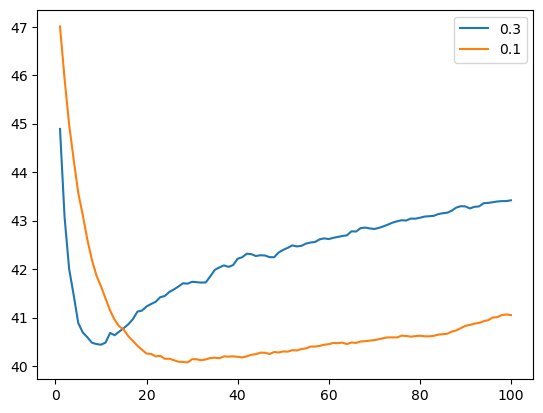

In [91]:
# plotting the results
plt.plot(df_results_3['round'], df_results_3['val_rmse'],
        label='0.3')
plt.plot(df_results_3['round'], df_results_1['val_rmse'],
        label='0.1')
plt.legend()
plt.show()

answer: interesting results but from the plot it appears that the eta of 0.1 performs much better on validation rmse.

In [80]:
evals_result

dict_keys(['train', 'val'])